# Modeling
## Home Credit Default Risk

**Author:** Oknardo Tulung  
**LinkedIn:** https://www.linkedin.com/in/oknardo-tulung/  
**GitHub:** https://github.com/oknardo/Home_Credit_Scorecard_Model

---

## 📌 Project Overview
This notebook builds and evaluates multiple machine learning models to predict loan default risk using the clean merged dataset prepared in `Data Cleaning and Handling.ipynb`. The goal is to identify the best performing model while ensuring interpretability for credit scoring purposes.

---

## 🎯 Objectives
- Build and evaluate 6 machine learning models for default prediction
- Compare model performance across multiple evaluation metrics
- Identify the most important features driving default risk using SHAP analysis
- Generate actionable insights for credit risk management

---

## 🔍 Analysis Scope
The analysis includes:
- Train-test split with stratification to preserve class distribution
- Class imbalance handling using SMOTE
- Model training and hyperparameter tuning
- Comprehensive evaluation: Confusion Matrix, Classification Report, ROC-AUC, Gini, KS Statistic
- Model comparison across all metrics
- SHAP analysis for feature importance and interpretability

---

## 🧠 Key Questions
- Which model performs best for predicting loan default?
- What are the strongest predictors of default across all feature groups?
- How does each model balance precision and recall for the minority class?
- What business insights can be derived from model results?

---

## 🛠 Tools & Libraries
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- LightGBM
- XGBoost
- CatBoost
- Imbalanced-learn (SMOTE)
- SHAP

---

## 📊 Output
The output of this notebook will serve as:
- A trained and evaluated credit risk prediction model
- Feature importance rankings for business interpretation
- Model performance comparison for final model selection
- Input for scorecard development and deployment

# Importing Library

In [4]:
# Installation Library
!pip install seaborn scikit-learn lightgbm xgboost catboost shap imbalanced-learn 


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# Hide Warning
import warnings
warnings.filterwarnings('ignore')

# Importing Library
import pandas as pd
# Setting Pandas Row Display Max
pd.set_option('display.max_rows', None)

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score, accuracy_score
)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
import shap


# Importing Dataset

In [14]:
# Load clean dataset
clean_path = r'D:\Python\Projects\Project Scorecard Model Home Credit Indonesia\home-credit-default-risk\clean_dataset.csv'
df = pd.read_csv(clean_path)
print(f"Shape: {df.shape}")
print(f"Default rate: {df['TARGET'].mean() * 100:.2f}%")

Shape: (307511, 241)
Default rate: 8.07%


# Fix Infinity Values

In [15]:
# Check for infinity values
inf_cols = [col for col in X_train.columns if np.isinf(X_train[col]).any()]
print(f"Columns with infinity: {len(inf_cols)}")
print(inf_cols)

# Check for very large values
large_cols = [col for col in X_train.columns if (X_train[col].abs() > 1e15).any()]
print(f"\nColumns with very large values: {len(large_cols)}")
print(large_cols)

Columns with infinity: 1
['PREV_CREDIT_TO_APPLICATION_RATIO']

Columns with very large values: 1
['PREV_CREDIT_TO_APPLICATION_RATIO']


In [16]:
# Fix infinity in PREV_CREDIT_TO_APPLICATION_RATIO
df['PREV_CREDIT_TO_APPLICATION_RATIO'] = df['PREV_CREDIT_TO_APPLICATION_RATIO'].replace([np.inf, -np.inf], np.nan)
df['PREV_CREDIT_TO_APPLICATION_RATIO'] = df['PREV_CREDIT_TO_APPLICATION_RATIO'].fillna(0)

# Fix derived features that may have infinity
derived_ratio_cols = [
    'CREDIT_TO_INCOME_RATIO', 'ANNUITY_TO_INCOME_RATIO',
    'CREDIT_TO_ANNUITY_RATIO', 'EMPLOYED_TO_AGE_RATIO',
    'INCOME_PER_PERSON', 'CC_UTILIZATION_RATIO',
    'POS_INSTALMENT_COMPLETION_RATIO', 'INST_AMT_PAYMENT_RATIO'
]

for col in derived_ratio_cols:
    if col in df.columns:
        df[col] = df[col].replace([np.inf, -np.inf], np.nan)
        df[col] = df[col].fillna(0)

# Re-split after fix
X = df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Verify
inf_check = [col for col in X_train.columns if np.isinf(X_train[col]).any()]
print(f"Columns with infinity after fix: {len(inf_check)}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")

Columns with infinity after fix: 0
X_train shape: (246008, 239)
X_test shape : (61503, 239)


# 1. Train Test Split

This section splits the clean dataset into training and testing sets. Stratification is applied to preserve the class distribution of the target variable in both sets.

In [17]:
# Separate features and target
X = df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df['TARGET']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (307511, 239)
Target shape: (307511,)


In [18]:
# Train test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape    : {X_test.shape}")
print(f"Default rate - Train: {y_train.mean() * 100:.2f}%")
print(f"Default rate - Test : {y_test.mean() * 100:.2f}%")

Training set shape: (246008, 239)
Test set shape    : (61503, 239)
Default rate - Train: 8.07%
Default rate - Test : 8.07%


# 2. Handle Class Imbalance

The dataset is heavily imbalanced with only 8.07% default rate. SMOTE (Synthetic Minority Oversampling Technique) is applied to the training set only to balance the class distribution before model training. The test set is kept unchanged to ensure realistic evaluation.

In [19]:
# Apply SMOTE to training set only
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE:")
print(f"  Training set shape : {X_train.shape}")
print(f"  Default rate       : {y_train.mean() * 100:.2f}%")
print(f"  Non-default count  : {(y_train == 0).sum():,}")
print(f"  Default count      : {(y_train == 1).sum():,}")

print(f"\nAfter SMOTE:")
print(f"  Training set shape : {X_train_smote.shape}")
print(f"  Default rate       : {y_train_smote.mean() * 100:.2f}%")
print(f"  Non-default count  : {(y_train_smote == 0).sum():,}")
print(f"  Default count      : {(y_train_smote == 1).sum():,}")

Before SMOTE:
  Training set shape : (246008, 239)
  Default rate       : 8.07%
  Non-default count  : 226,148
  Default count      : 19,860

After SMOTE:
  Training set shape : (452296, 239)
  Default rate       : 50.00%
  Non-default count  : 226,148
  Default count      : 226,148


# 3. Logistic Regression

Logistic Regression is a linear model that estimates the probability of default based on a weighted combination of input features. It serves as the interpretable baseline model and is required for scorecard development.

## 3.1 Training

In [20]:
# Initialize and train Logistic Regression
lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

lr.fit(X_train_smote, y_train_smote)
print("Logistic Regression training completed.")

Logistic Regression training completed.


## 3.2 Evaluation

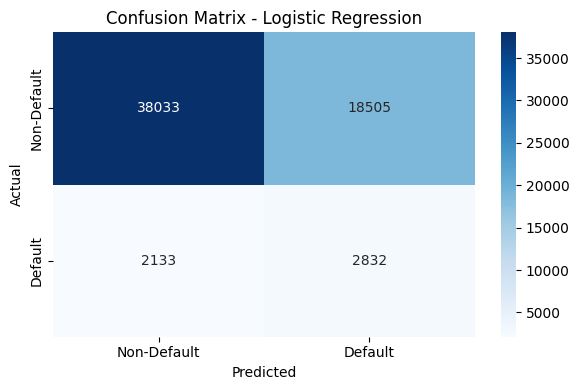

In [21]:
# Predictions
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Default', 'Default'],
            yticklabels=['Non-Default', 'Default'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [22]:
# Classification Report
print("Classification Report - Logistic Regression")
print(classification_report(y_test, y_pred_lr, target_names=['Non-Default', 'Default']))

# ROC-AUC
auc_lr = roc_auc_score(y_test, y_prob_lr)
gini_lr = 2 * auc_lr - 1

# KS Statistic
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_prob_lr)
ks_lr = max(tpr_lr - fpr_lr)

print(f"ROC-AUC Score : {auc_lr:.4f}")
print(f"Gini          : {gini_lr:.4f}")
print(f"KS Statistic  : {ks_lr:.4f}")

Classification Report - Logistic Regression
              precision    recall  f1-score   support

 Non-Default       0.95      0.67      0.79     56538
     Default       0.13      0.57      0.22      4965

    accuracy                           0.66     61503
   macro avg       0.54      0.62      0.50     61503
weighted avg       0.88      0.66      0.74     61503

ROC-AUC Score : 0.6643
Gini          : 0.3286
KS Statistic  : 0.2502


### Key Findings

**Model Performance**
Logistic Regression achieves a ROC-AUC of **0.6643** with a Gini coefficient of **0.3286** and KS Statistic of **0.2502**, indicating moderate discriminative power as expected for a linear baseline model.

**Class Imbalance Handling**
SMOTE effectively improved recall for the Default class to **0.57**, meaning the model correctly identifies 57% of actual defaulters. However, precision for Default is only **0.13**, indicating a high false positive rate where many non-defaulters are predicted as defaulters.

**Confusion Matrix Insights**
- True Negatives (correctly predicted non-default): 38,033
- False Positives (non-default predicted as default): 18,505
- False Negatives (default predicted as non-default): 2,133
- True Positives (correctly predicted default): 2,832

**Trade-off Observation**
The model prioritizes recall over precision for the default class, which is acceptable in credit risk context where missing a defaulter (False Negative) is more costly than incorrectly flagging a non-defaulter (False Positive). However, the low precision (0.13) may lead to excessive loan rejections.

**Baseline Established**
As a linear model, Logistic Regression serves as the interpretable baseline. Tree-based ensemble models are expected to significantly outperform this result.

---

# 4. Decision Tree

A Decision Tree is a non-linear model that splits data based on feature thresholds to create a tree-like structure for classification. It serves as an interpretable tree-based baseline before moving to ensemble methods.

## 4.1 Training

In [24]:
# Initialize and train Decision Tree
dt = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=50,
    min_samples_leaf=25,
    random_state=42,
    class_weight='balanced'
)

dt.fit(X_train_smote, y_train_smote)
print("Decision Tree training completed.")

Decision Tree training completed.


## 4.2 Evaluation

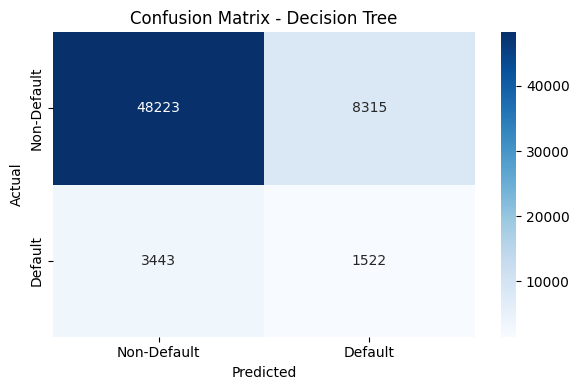

In [25]:
# Predictions
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Default', 'Default'],
            yticklabels=['Non-Default', 'Default'])
plt.title('Confusion Matrix - Decision Tree')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [26]:
# Classification Report
print("Classification Report - Decision Tree")
print(classification_report(y_test, y_pred_dt, target_names=['Non-Default', 'Default']))

# ROC-AUC
auc_dt = roc_auc_score(y_test, y_prob_dt)
gini_dt = 2 * auc_dt - 1

# KS Statistic
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_prob_dt)
ks_dt = max(tpr_dt - fpr_dt)

print(f"ROC-AUC Score : {auc_dt:.4f}")
print(f"Gini          : {gini_dt:.4f}")
print(f"KS Statistic  : {ks_dt:.4f}")

Classification Report - Decision Tree
              precision    recall  f1-score   support

 Non-Default       0.93      0.85      0.89     56538
     Default       0.15      0.31      0.21      4965

    accuracy                           0.81     61503
   macro avg       0.54      0.58      0.55     61503
weighted avg       0.87      0.81      0.84     61503

ROC-AUC Score : 0.6727
Gini          : 0.3454
KS Statistic  : 0.2828


### Key Findings

**Model Performance**
Decision Tree achieves a ROC-AUC of **0.6727** with a Gini coefficient of **0.3454** and KS Statistic of **0.2828**, indicating moderate discriminative power for default prediction.

**Confusion Matrix Insights**
- True Negatives (correctly predicted non-default): 48,223
- False Positives (non-default predicted as default): 8,315
- False Negatives (default predicted as non-default): 3,443
- True Positives (correctly predicted default): 1,522

**Precision vs Recall Trade-off**
The model shows higher precision for Non-Default (0.93) but struggles with Default class (precision 0.15, recall 0.31), indicating the model tends to predict most applicants as non-default. This is a common behavior for tree models on imbalanced datasets even after SMOTE.

**Overall Accuracy**
Accuracy of **0.81** is driven primarily by correct non-default predictions, which dominate the dataset. This metric alone is not sufficient for evaluating credit risk models.

---

# 5. Random Forest

Random Forest is an ensemble model that builds multiple decision trees on random subsets of data and features, then aggregates their predictions. It reduces overfitting compared to a single Decision Tree and generally produces more robust predictions.

## 5.1 Training

In [28]:
# Initialize and train Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=50,
    min_samples_leaf=25,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf.fit(X_train_smote, y_train_smote)
print("Random Forest training completed.")

Random Forest training completed.


## 5.2 Evaluation

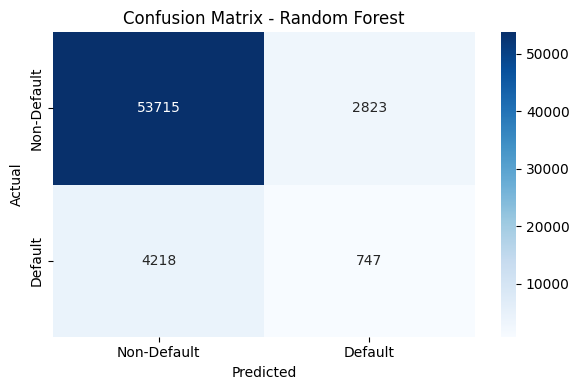

In [29]:
# Predictions
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Default', 'Default'],
            yticklabels=['Non-Default', 'Default'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [30]:
# Classification Report
print("Classification Report - Random Forest")
print(classification_report(y_test, y_pred_rf, target_names=['Non-Default', 'Default']))

# ROC-AUC
auc_rf = roc_auc_score(y_test, y_prob_rf)
gini_rf = 2 * auc_rf - 1

# KS Statistic
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)
ks_rf = max(tpr_rf - fpr_rf)

print(f"ROC-AUC Score : {auc_rf:.4f}")
print(f"Gini          : {gini_rf:.4f}")
print(f"KS Statistic  : {ks_rf:.4f}")

Classification Report - Random Forest
              precision    recall  f1-score   support

 Non-Default       0.93      0.95      0.94     56538
     Default       0.21      0.15      0.18      4965

    accuracy                           0.89     61503
   macro avg       0.57      0.55      0.56     61503
weighted avg       0.87      0.89      0.88     61503

ROC-AUC Score : 0.7112
Gini          : 0.4224
KS Statistic  : 0.3228


### Key Findings 

**Model Performance**
Random Forest achieves a ROC-AUC of **0.7112** with a Gini coefficient of **0.4224** and KS Statistic of **0.3228**, showing meaningful improvement in discriminative power over single tree models.

**Confusion Matrix Insights**
- True Negatives (correctly predicted non-default): 53,715
- False Positives (non-default predicted as default): 2,823
- False Negatives (default predicted as non-default): 4,218
- True Positives (correctly predicted default): 747

**Precision vs Recall Trade-off**
The model shows strong performance on Non-Default class (precision 0.93, recall 0.95) but struggles significantly with Default class (precision 0.21, recall 0.15). The model correctly identifies only 15% of actual defaulters, indicating it heavily favors the majority class despite SMOTE balancing.

**Overall Accuracy**
Accuracy of **0.89** is the highest so far but is largely driven by excellent non-default prediction. In credit risk context, the low recall for Default class (0.15) means 4,218 defaulters are incorrectly approved, representing significant financial risk.

---

# 6. LightGBM

LightGBM is a gradient boosting framework that uses tree-based learning with leaf-wise growth strategy. It is highly efficient on large datasets and generally produces strong performance on tabular data.

## 6.1 Training

In [32]:
# Initialize and train LightGBM
lgbm = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=31,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train_smote == 0).sum() / (y_train_smote == 1).sum(),
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm.fit(X_train_smote, y_train_smote)
print("LightGBM training completed.")

LightGBM training completed.


## 6.2 Evaluation

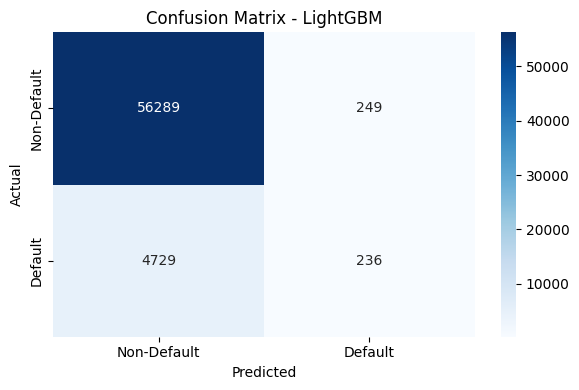

In [33]:
# Predictions
y_pred_lgbm = lgbm.predict(X_test)
y_prob_lgbm = lgbm.predict_proba(X_test)[:, 1]

# Confusion Matrix
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Default', 'Default'],
            yticklabels=['Non-Default', 'Default'])
plt.title('Confusion Matrix - LightGBM')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [34]:
# Classification Report
print("Classification Report - LightGBM")
print(classification_report(y_test, y_pred_lgbm, target_names=['Non-Default', 'Default']))

# ROC-AUC
auc_lgbm = roc_auc_score(y_test, y_prob_lgbm)
gini_lgbm = 2 * auc_lgbm - 1

# KS Statistic
fpr_lgbm, tpr_lgbm, thresholds_lgbm = roc_curve(y_test, y_prob_lgbm)
ks_lgbm = max(tpr_lgbm - fpr_lgbm)

print(f"ROC-AUC Score : {auc_lgbm:.4f}")
print(f"Gini          : {gini_lgbm:.4f}")
print(f"KS Statistic  : {ks_lgbm:.4f}")

Classification Report - LightGBM
              precision    recall  f1-score   support

 Non-Default       0.92      1.00      0.96     56538
     Default       0.49      0.05      0.09      4965

    accuracy                           0.92     61503
   macro avg       0.70      0.52      0.52     61503
weighted avg       0.89      0.92      0.89     61503

ROC-AUC Score : 0.7802
Gini          : 0.5603
KS Statistic  : 0.4256


### Key Findings

**Model Performance**
LightGBM achieves the highest ROC-AUC so far at **0.7802** with Gini of **0.5603** and KS Statistic of **0.4256**, confirming its strong discriminative power on tabular data.

**Confusion Matrix Insights**
- True Negatives (correctly predicted non-default): 56,289
- False Positives (non-default predicted as default): 249
- False Negatives (default predicted as non-default): 4,729
- True Positives (correctly predicted default): 236

**Precision vs Recall Trade-off**
Despite strong ROC-AUC, the model shows extremely low recall for Default class (0.05), meaning only 5% of actual defaulters are correctly identified. The model is heavily biased toward predicting Non-Default, driven by the combination of SMOTE and scale_pos_weight.

**High ROC-AUC vs Low Recall**
ROC-AUC of 0.78 indicates the model's probability scores are well-ranked, but the default classification threshold needs adjustment. Lowering the decision threshold from 0.5 could significantly improve recall at the cost of precision.

---

# 7. XGBoost

XGBoost is a gradient boosting framework known for its speed and performance. It uses level-wise tree growth with regularization to prevent overfitting, making it robust for credit risk prediction on large datasets.

## 7.1 Training

In [36]:
# Initialize and train XGBoost
xgboost = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc',
    verbosity=0
)

xgboost.fit(X_train_smote, y_train_smote)
print("XGBoost training completed.")

XGBoost training completed.


## 7.2 Evaluation

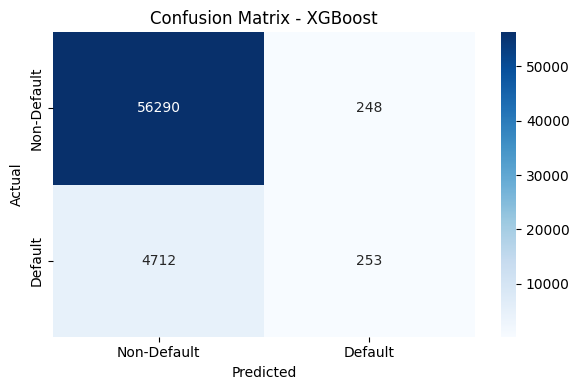

In [37]:
# Predictions
y_pred_xgb = xgboost.predict(X_test)
y_prob_xgb = xgboost.predict_proba(X_test)[:, 1]

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Default', 'Default'],
            yticklabels=['Non-Default', 'Default'])
plt.title('Confusion Matrix - XGBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [38]:
# Classification Report
print("Classification Report - XGBoost")
print(classification_report(y_test, y_pred_xgb, target_names=['Non-Default', 'Default']))

# ROC-AUC
auc_xgb = roc_auc_score(y_test, y_prob_xgb)
gini_xgb = 2 * auc_xgb - 1

# KS Statistic
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_prob_xgb)
ks_xgb = max(tpr_xgb - fpr_xgb)

print(f"ROC-AUC Score : {auc_xgb:.4f}")
print(f"Gini          : {gini_xgb:.4f}")
print(f"KS Statistic  : {ks_xgb:.4f}")

Classification Report - XGBoost
              precision    recall  f1-score   support

 Non-Default       0.92      1.00      0.96     56538
     Default       0.50      0.05      0.09      4965

    accuracy                           0.92     61503
   macro avg       0.71      0.52      0.53     61503
weighted avg       0.89      0.92      0.89     61503

ROC-AUC Score : 0.7794
Gini          : 0.5587
KS Statistic  : 0.4204


### Key Findings - XGBoost

**Model Performance**
XGBoost achieves a ROC-AUC of **0.7794** with Gini of **0.5587** and KS Statistic of **0.4204**, showing strong discriminative power comparable to LightGBM.

**Confusion Matrix Insights**
- True Negatives (correctly predicted non-default): 56,290
- False Positives (non-default predicted as default): 248
- False Negatives (default predicted as non-default): 4,712
- True Positives (correctly predicted default): 253

**Precision vs Recall Trade-off**
Similar pattern to LightGBM with very low recall for Default class (0.05). The model correctly identifies only 5% of actual defaulters despite strong ROC-AUC, indicating the decision threshold of 0.5 is not optimal for this imbalanced problem. Precision for Default (0.50) is relatively high, meaning when the model does predict default, it is correct half the time.

**High ROC-AUC vs Low Recall**
ROC-AUC of 0.78 confirms well-ranked probability scores. Threshold optimization post-training could significantly improve recall for the Default class at the cost of some precision.

---

# 8. CatBoost

CatBoost is a gradient boosting framework developed by Yandex that handles categorical features natively and uses ordered boosting to reduce overfitting. It generally requires less hyperparameter tuning compared to LightGBM and XGBoost while delivering competitive performance.

## 8.1 Training

In [40]:
# Initialize and train CatBoost
catboost = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    subsample=0.8,
    random_state=42,
    verbose=0
)

catboost.fit(X_train_smote, y_train_smote)
print("CatBoost training completed.")

CatBoost training completed.


## 8.2 Evaluation

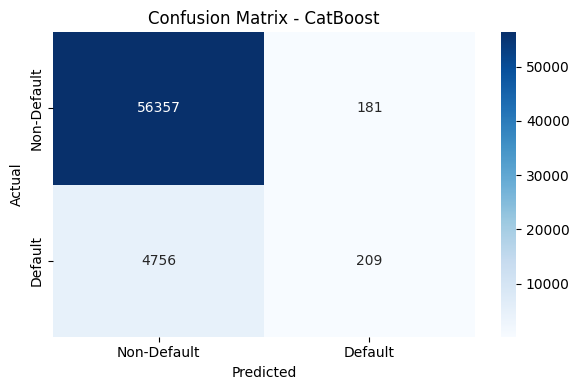

In [41]:
# Predictions
y_pred_cb = catboost.predict(X_test)
y_prob_cb = catboost.predict_proba(X_test)[:, 1]

# Confusion Matrix
cm_cb = confusion_matrix(y_test, y_pred_cb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_cb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Default', 'Default'],
            yticklabels=['Non-Default', 'Default'])
plt.title('Confusion Matrix - CatBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [42]:
# Classification Report
print("Classification Report - CatBoost")
print(classification_report(y_test, y_pred_cb, target_names=['Non-Default', 'Default']))

# ROC-AUC
auc_cb = roc_auc_score(y_test, y_prob_cb)
gini_cb = 2 * auc_cb - 1

# KS Statistic
fpr_cb, tpr_cb, thresholds_cb = roc_curve(y_test, y_prob_cb)
ks_cb = max(tpr_cb - fpr_cb)

print(f"ROC-AUC Score : {auc_cb:.4f}")
print(f"Gini          : {gini_cb:.4f}")
print(f"KS Statistic  : {ks_cb:.4f}")

Classification Report - CatBoost
              precision    recall  f1-score   support

 Non-Default       0.92      1.00      0.96     56538
     Default       0.54      0.04      0.08      4965

    accuracy                           0.92     61503
   macro avg       0.73      0.52      0.52     61503
weighted avg       0.89      0.92      0.89     61503

ROC-AUC Score : 0.7761
Gini          : 0.5522
KS Statistic  : 0.4211


### Key Findings 

**Model Performance**
CatBoost achieves a ROC-AUC of **0.7761** with Gini of **0.5522** and KS Statistic of **0.4211**, delivering competitive performance with minimal hyperparameter tuning.

**Confusion Matrix Insights**
- True Negatives (correctly predicted non-default): 56,357
- False Positives (non-default predicted as default): 181
- False Negatives (default predicted as non-default): 4,756
- True Positives (correctly predicted default): 209

**Precision vs Recall Trade-off**
CatBoost shows the highest precision for Default class among all models so far at **0.54**, meaning when it predicts default it is correct 54% of the time. However recall remains very low at **0.04**, identifying only 4% of actual defaulters. The model is highly selective but misses the majority of default cases.

**Overall Accuracy**
Accuracy of **0.92** is driven by strong non-default prediction performance (recall 1.00). Similar to LightGBM and XGBoost, threshold optimization is needed to improve default detection rate.

---

# 9. Model Comparison

This section compares all six models across key evaluation metrics to identify the best performing model for credit default prediction.

In [48]:
# Compile all metrics into a comparison table
model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'LightGBM',
        'XGBoost',
        'CatBoost'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_lgbm),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_cb)
    ],
    'Precision (Default)': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_lgbm),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_cb)
    ],
    'Recall (Default)': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_lgbm),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_cb)
    ],
    'F1 (Default)': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_lgbm),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_cb)
    ],
    'ROC-AUC': [auc_lr, auc_dt, auc_rf, auc_lgbm, auc_xgb, auc_cb],
    'Gini': [gini_lr, gini_dt, gini_rf, gini_lgbm, gini_xgb, gini_cb],
    'KS Statistic': [ks_lr, ks_dt, ks_rf, ks_lgbm, ks_xgb, ks_cb]
}).round(4)

model_comparison = model_comparison.set_index('Model')
model_comparison

,Accuracy,Precision (Default),Recall (Default),F1 (Default),ROC-AUC,Gini,KS Statistic
Model,,,,,,,
Logistic Regression,0.6644,0.1327,0.5704,0.2153,0.6643,0.3286,0.2502
Decision Tree,0.8088,0.1547,0.3065,0.2056,0.6727,0.3454,0.2828
Random Forest,0.8855,0.2092,0.1505,0.1750,0.7112,0.4224,0.3228
LightGBM,0.9191,0.4866,0.0475,0.0866,0.7802,0.5603,0.4256
XGBoost,0.9194,0.5050,0.0510,0.0926,0.7794,0.5587,0.4204
CatBoost,0.9197,0.5359,0.0421,0.0781,0.7761,0.5522,0.4211


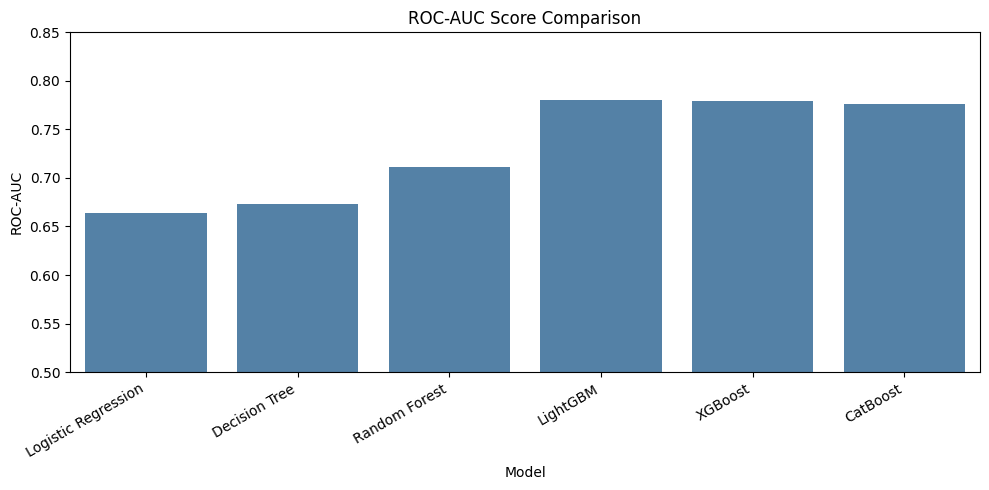

In [45]:
# Visualization - ROC-AUC comparison
plt.figure(figsize=(10, 5))
sns.barplot(x=model_comparison.index, y=model_comparison['ROC-AUC'], color='steelblue')
plt.title('ROC-AUC Score Comparison')
plt.ylabel('ROC-AUC')
plt.xlabel('Model')
plt.xticks(rotation=30, ha='right')
plt.ylim(0.5, 0.85)
plt.tight_layout()
plt.show()

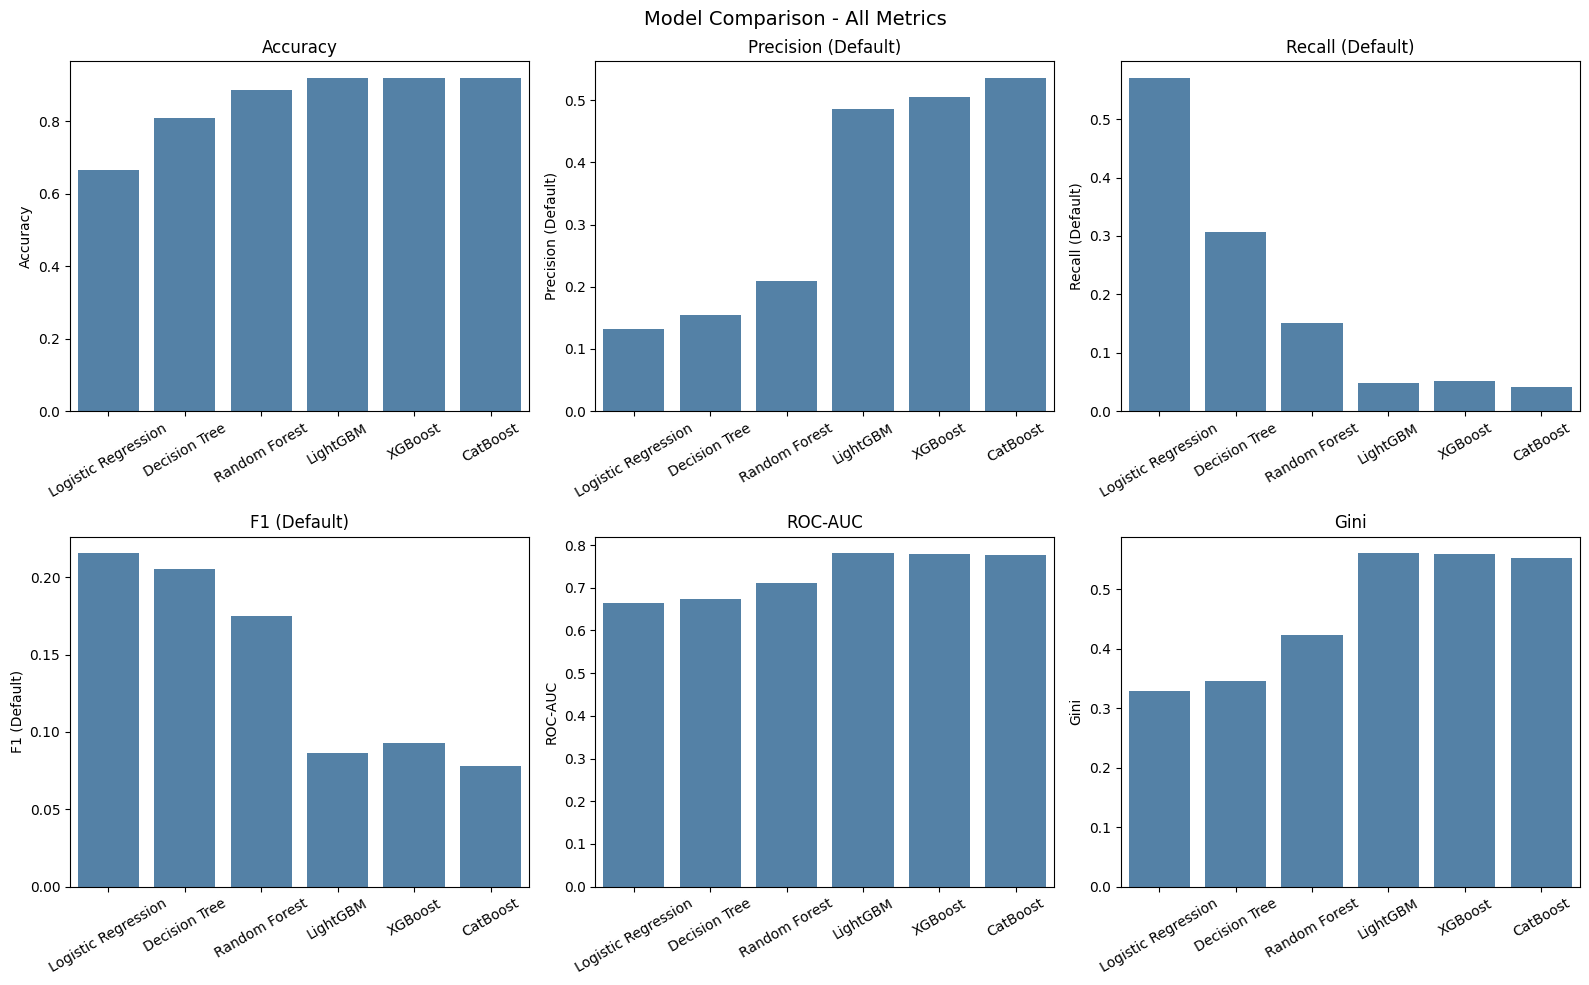

In [46]:
# Visualization - All metrics comparison
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

metrics = ['Accuracy', 'Precision (Default)', 'Recall (Default)',
           'F1 (Default)', 'ROC-AUC', 'Gini']

for i, metric in enumerate(metrics):
    sns.barplot(x=model_comparison.index, y=model_comparison[metric],
                ax=axes[i], color='steelblue')
    axes[i].set_title(metric)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Model Comparison - All Metrics', fontsize=14)
plt.tight_layout()
plt.show()

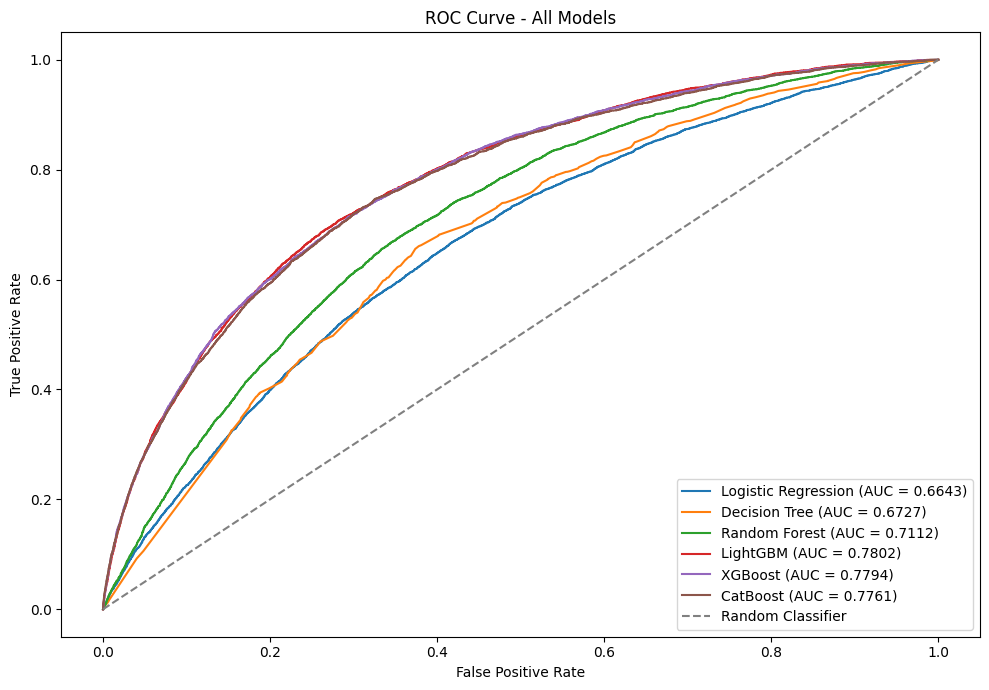

In [47]:
# ROC Curve - All models
plt.figure(figsize=(10, 7))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.4f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.4f})')
plt.plot(fpr_lgbm, tpr_lgbm, label=f'LightGBM (AUC = {auc_lgbm:.4f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.4f})')
plt.plot(fpr_cb, tpr_cb, label=f'CatBoost (AUC = {auc_cb:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.title('ROC Curve - All Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Key Findings - Model Comparison

**ROC-AUC Rankings**
LightGBM leads with the highest ROC-AUC of **0.7802**, followed closely by XGBoost (0.7794) and CatBoost (0.7761). All three gradient boosting models significantly outperform the baseline models in discriminative power.

**Gradient Boosting vs Traditional Models**
The three gradient boosting models (LightGBM, XGBoost, CatBoost) consistently outperform Logistic Regression, Decision Tree, and Random Forest across ROC-AUC, Gini, and KS Statistic. This confirms that non-linear ensemble methods are better suited for this credit risk problem.

**Precision vs Recall Trade-off Across All Models**
A clear trade-off pattern emerges: models with higher ROC-AUC (gradient boosting) show higher precision but extremely low recall for Default class, while simpler models (Logistic Regression) sacrifice precision for higher recall. No single model achieves a good balance between precision and recall for the Default class.

**Best Model by Metric:**
- **ROC-AUC**: LightGBM (0.7802)
- **Gini**: LightGBM (0.5603)
- **KS Statistic**: LightGBM (0.4256)
- **Recall (Default)**: Logistic Regression (0.5704)
- **Precision (Default)**: CatBoost (0.5359)
- **Accuracy**: CatBoost (0.9197)

**Threshold Optimization Needed**
All gradient boosting models show recall below 0.05 for Default class at the default threshold of 0.5. Lowering the classification threshold would significantly improve recall at the cost of precision, which may be preferable in credit risk context where missing a defaulter is more costly than incorrectly rejecting a non-defaulter.

**Selected Model for SHAP Analysis**
LightGBM is selected as the primary model for SHAP analysis in Section 10, as it achieves the best overall discriminative performance with the highest ROC-AUC, Gini, and KS Statistic.

---

# 10. SHAP Analysis

SHAP (SHapley Additive exPlanations) provides a unified framework for interpreting machine learning model predictions. It assigns each feature an importance value for a particular prediction, based on game theory principles. LightGBM is used as the basis for SHAP analysis as it achieved the best overall performance.

In [56]:
# Initialize SHAP explainer for LightGBM
explainer = shap.TreeExplainer(lgbm)

# Calculate SHAP values on a sample for efficiency
sample_size = 5000
X_test_sample = X_test.sample(n=sample_size, random_state=42)
shap_values = explainer.shap_values(X_test_sample)

# Fix: use correct shap values format
shap_vals = shap_values[1] if isinstance(shap_values, list) else shap_values

print(f"SHAP values calculated for {sample_size} samples.")
print(f"SHAP values shape: {shap_vals.shape}")

SHAP values calculated for 5000 samples.
SHAP values shape: (5000, 239)


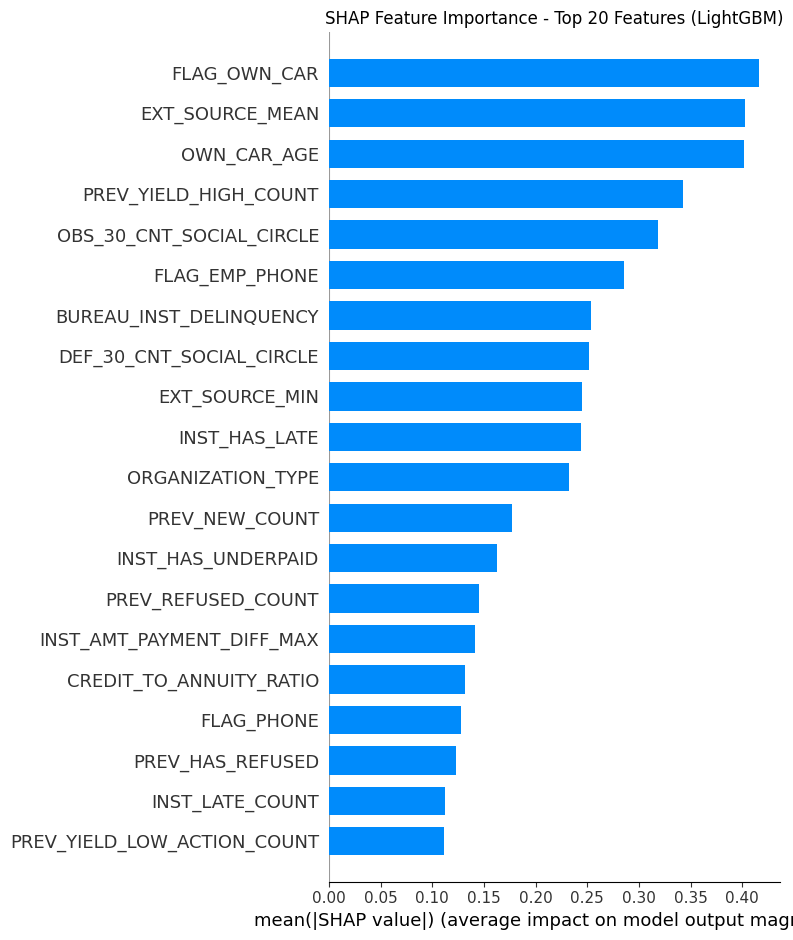

In [57]:
# SHAP Feature Importance - Bar Plot
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_vals, X_test_sample, plot_type='bar', max_display=20, show=False)
plt.title('SHAP Feature Importance - Top 20 Features (LightGBM)')
plt.tight_layout()
plt.show()

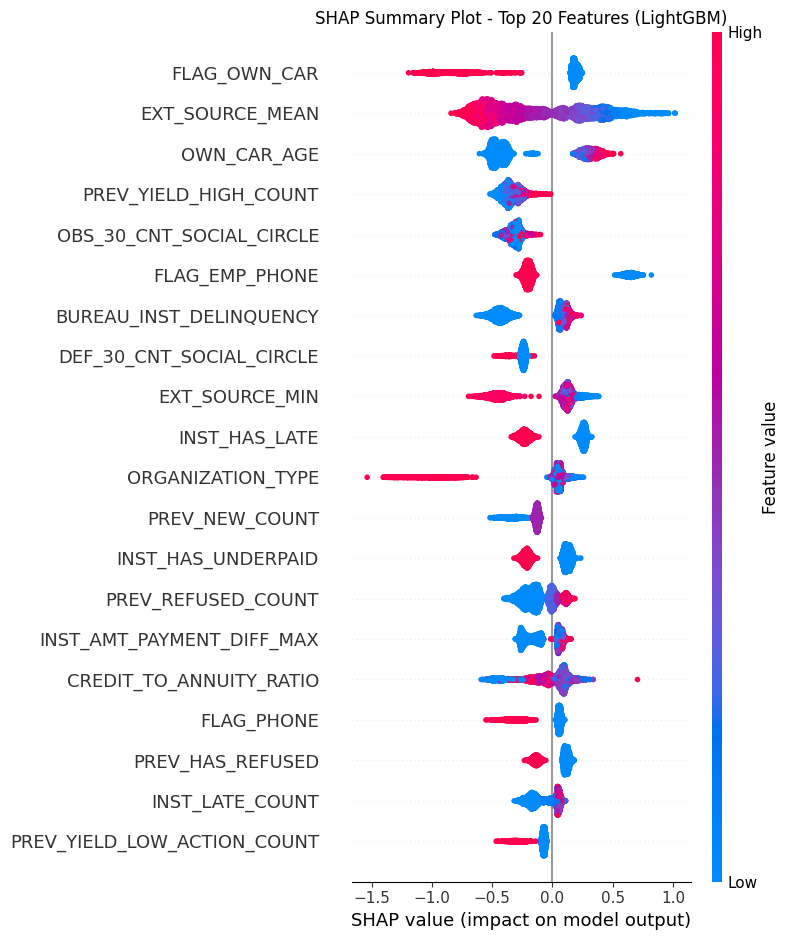

In [58]:
# SHAP Summary Plot - Beeswarm
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_vals, X_test_sample, max_display=20, show=False)
plt.title('SHAP Summary Plot - Top 20 Features (LightGBM)')
plt.tight_layout()
plt.show()

Top 3 features: ['FLAG_OWN_CAR', 'EXT_SOURCE_MEAN', 'OWN_CAR_AGE']


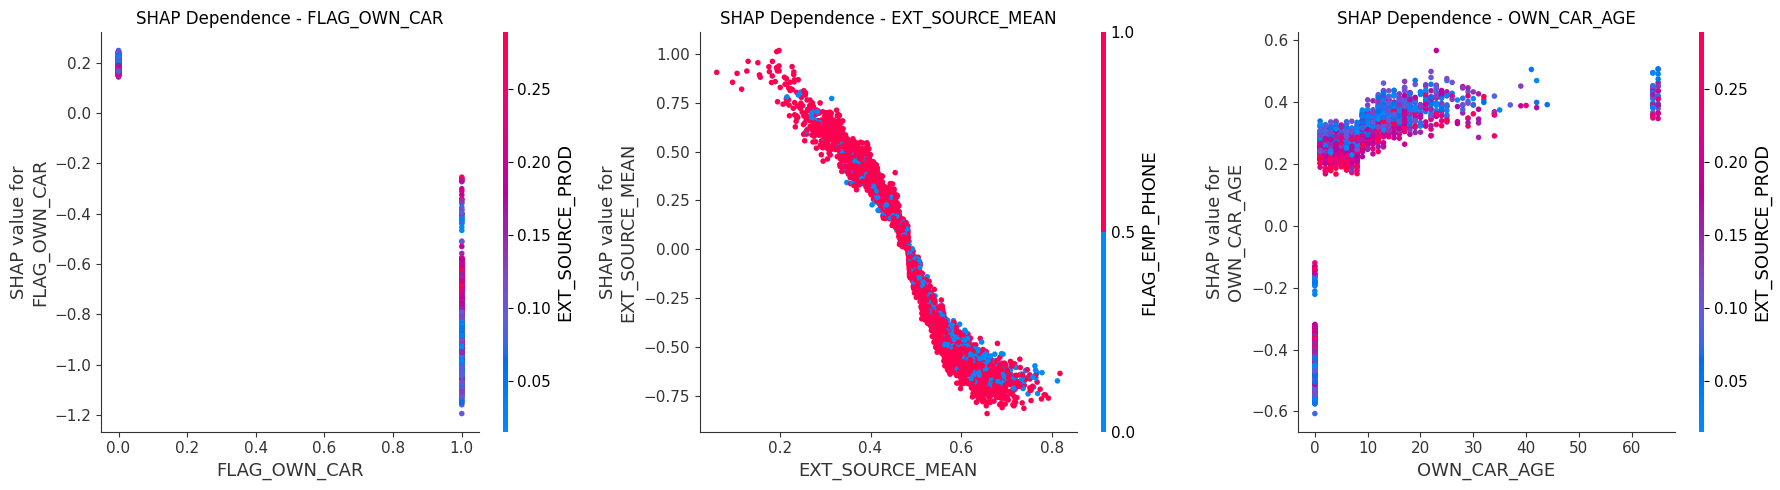

In [59]:
# Top 3 features by SHAP importance
top_features = pd.DataFrame({
    'Feature': X_test_sample.columns,
    'SHAP_Importance': np.abs(shap_vals).mean(axis=0)
}).sort_values('SHAP_Importance', ascending=False)

top_3 = top_features.head(3)['Feature'].tolist()
print(f"Top 3 features: {top_3}")

# SHAP Dependence Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, feature in enumerate(top_3):
    shap.dependence_plot(feature, shap_vals, X_test_sample, ax=axes[i], show=False)
    axes[i].set_title(f'SHAP Dependence - {feature}')

plt.tight_layout()
plt.show()